In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rc('font', size=14)
np.set_printoptions(precision=5, suppress=True)

# ---------------------------------------------------------------------
# INPUTS
# ---------------------------------------------------------------------

airfoil_file = "s7055.dat"

# Wing / section data
chord = 0.265
skin_thickness = 0.5e-3

# Stringer geometry
stringer_thickness = 0.5e-3
stringer_length = 20e-3

# Number of stringers to add.
# Change this to match your section.
num_stringers = 7

# Stringer positions as normalized chordwise coordinates (x/c)
#
# Enter upper and lower stringer locations separately.
#
# Example:
# upper_stringer_x_norm = np.array([0.10, 0.30, 0.70, 0.90])
# lower_stringer_x_norm = np.array([0.10, 0.30, 0.70, 0.90])
#
# x/c = 0 -> Leading Edge
# x/c = 1 -> Trailing Edge

upper_stringer_x_norm = np.array([0.1, 0.3, 0.7, 0.9])
lower_stringer_x_norm = np.array([0.2,0.4,0.7])

# Vertical shear force used only to obtain the shear-center moment.
# The resulting shear-center location is independent of its magnitude.
V = 1.0  # N

spar_location_norm = 0.3174
spar_location = spar_location_norm*chord
theo_spar_height = 0.028
flange_length = 0.03
flange_thickness = 1e-3
web_thickness = 1e-3

In [2]:
Xref = 0.25
Cmref = -0.073
CL = 0.72
Xcp = Xref - Cmref/CL
print(f"Chordwise Position of Center of Pressure (from LE) = {Xcp:.2g}")

Chordwise Position of Center of Pressure (from LE) = 0.35


In [3]:
# LOAD AIRFOIL
# ---------------------------------------------------------------------

airfoil = np.loadtxt(airfoil_file) * chord

# Selig coordinates contain a duplicate trailing-edge point.
# Remove the final duplicate if it is coincident with the first point.
if np.allclose(airfoil[0], airfoil[-1]):
    airfoil = airfoil[:-1]

x = airfoil[:, 0]
y = airfoil[:, 1]

n = len(x)

# Closed panels
x_next = np.roll(x, -1)
y_next = np.roll(y, -1)

dx = x_next - x
dy = y_next - y
ds = np.hypot(dx, dy)

# Panel midpoints
x_mid = 0.5 * (x + x_next)
y_mid = 0.5 * (y + y_next)


In [4]:
n_points = len(airfoil)
print(n_points)

80


In [5]:
# ---------------------------------------------------------------------
# 1. SKIN AREA IDEALISATION
# ---------------------------------------------------------------------

A_skin_panel = skin_thickness * ds
A_skin = np.sum(A_skin_panel)

x_centroid_skin = np.sum(A_skin_panel * x_mid) / A_skin
y_centroid_skin = np.sum(A_skin_panel * y_mid) / A_skin

print(f"Skin area       = {A_skin:.6e} m^2")
print(f"Skin centroid x = {x_centroid_skin:.6e} m")
print(f"Skin centroid y = {y_centroid_skin:.6e} m")

yc_skin = y - y_centroid_skin

# Check for points too close to the reference axis.
if np.any(np.abs(yc_skin) < 1e-10):
    raise ValueError(
        "A boom lies essentially on the skin centroidal axis. "
        "The standard boom-area formula becomes singular. "
        "Use a different boom/reference discretisation."
    )

l_prev = np.roll(ds, 1)
l_next = ds

y_prev = np.roll(yc_skin, 1)
y_next = np.roll(yc_skin, -1)

B_skin = (
    skin_thickness / 6.0
    * (
        l_prev * (2.0 + y_prev / yc_skin)
        + l_next * (2.0 + y_next / yc_skin)
    )
)


Skin area       = 2.695333e-04 m^2
Skin centroid x = 1.311096e-01 m
Skin centroid y = 6.145572e-03 m


In [6]:

# ---------------------------------------------------------------------
# 3. ADD STRINGER BOOM AREAS
# ---------------------------------------------------------------------

B_stringer = np.zeros(n)

# Stringer boom area
A_stringer = stringer_thickness * stringer_length


def find_surface_index(x_norm, surface):
    """
    Find the S7055 coordinate closest to the requested x/c
    on either the upper or lower surface.
    """

    x_target = x_norm * chord

    if surface == "upper":
        candidates = np.where(y >= 0)[0]
    elif surface == "lower":
        candidates = np.where(y <= 0)[0]
    else:
        raise ValueError("surface must be 'upper' or 'lower'")

    if len(candidates) == 0:
        raise ValueError(f"No points found on {surface} surface.")

    idx = candidates[np.argmin(np.abs(x[candidates] - x_target))]

    return idx


# -------------------------
# Upper stringers
# -------------------------

upper_stringer_indices = []

for x_norm in upper_stringer_x_norm:

    if not 0 <= x_norm <= 1:
        raise ValueError(
            f"Upper stringer x/c = {x_norm} is outside 0 <= x/c <= 1."
        )

    idx = find_surface_index(x_norm, "upper")

    B_stringer[idx] += A_stringer

    upper_stringer_indices.append(idx)


# -------------------------
# Lower stringers
# -------------------------

lower_stringer_indices = []

for x_norm in lower_stringer_x_norm:

    if not 0 <= x_norm <= 1:
        raise ValueError(
            f"Lower stringer x/c = {x_norm} is outside 0 <= x/c <= 1."
        )

    idx = find_surface_index(x_norm, "lower")

    B_stringer[idx] += A_stringer

    lower_stringer_indices.append(idx)


# Total boom area
B_total = B_skin + B_stringer


In [7]:
upper_spar_index = find_surface_index(spar_location_norm, "upper")
lower_spar_index = find_surface_index(spar_location_norm, "lower")

upper_flange_location = spar_location + flange_length
lower_flange_location = spar_location + flange_length

upper_flange_index = find_surface_index(upper_flange_location / chord, "upper")
lower_flange_index = find_surface_index(lower_flange_location / chord, "lower")

print(f"Upper spar index: {upper_spar_index}")
print(f"Upper flange index: {upper_flange_index}")
print(f"Lower spar index: {lower_spar_index}")
print(f"Lower flange index: {lower_flange_index}")

Upper spar index: 25
Upper flange index: 22
Lower spar index: 57
Lower flange index: 60


In [8]:
spar_height = y[upper_spar_index] - y[lower_spar_index]
print(f"Spar height: {spar_height}" , 
      f"theoretical spar height: {theo_spar_height}" )

Spar height: 0.0277455 theoretical spar height: 0.028


In [9]:
# Adding Bigger web booms

Boom_upper_spar = web_thickness*spar_height*(2+y[lower_spar_index]/y[upper_spar_index])/6 \
    + flange_thickness*ds[upper_spar_index-1]*(2+y[upper_spar_index-1]/y[upper_spar_index])/6

Boom_lower_spar = web_thickness*spar_height*(2+y[upper_spar_index]/y[lower_spar_index])/6 \
    + flange_thickness*ds[lower_spar_index-1]*(2+y[lower_spar_index-1]/y[lower_spar_index])/6

B_total[upper_spar_index] += Boom_upper_spar
B_total[lower_spar_index] += Boom_lower_spar
# adding upper flange booms

for i in range(upper_flange_index, upper_spar_index):
    if i == upper_flange_index:
        B_total[i] += flange_thickness*ds[i]*(2+y[i+1]/y[i])/6 
    else:
        B_total[i] += flange_thickness*ds[i-1]*(2+y[i-1]/y[i])/6 + flange_thickness*ds[i]*(2+y[i+1]/y[i])/6

# adding lower flange booms

for i in range(lower_spar_index + 1, lower_flange_index + 1):
    if i == lower_flange_index:
        B_total[i] += flange_thickness*ds[i-1]*(2+y[i-1]/y[i])/6 
    else:
        B_total[i] += flange_thickness*ds[i-1]*(2+y[i-1]/y[i])/6 + flange_thickness*ds[i]*(2+y[i+1]/y[i])/6

In [10]:
x_centroid_pt = np.sum(B_total * x_mid) / np.sum(B_total)
y_centroid_pt = np.sum(B_total * y_mid) / np.sum(B_total)

x_centroid = x - x_centroid_pt
y_centroid = y - y_centroid_pt

I_xx_centroid = np.sum(B_total*y_centroid**2)
I_yy_centroid = np.sum(B_total*x_centroid**2)
I_xy_centroid = np.sum(B_total*x_centroid*y_centroid)
D = I_xx_centroid*I_yy_centroid - I_xy_centroid**2

In [11]:
# we will make cut on the spar and the last panel

q_b_skin = np.zeros(n_points)


In [12]:
te_cut_panel = n_points-1
# ================================================================
# BASIC SHEAR FLOW WITH CUT AT TRAILING-EDGE PANEL
# ================================================================

q_b_panel = np.zeros(n)

# Panel 79 = trailing-edge cut
# Therefore reference basic shear flow at the cut is zero.
q_b_panel[te_cut_panel] = 0.0

q_running = 0.0

# Panels 0 -> 78
for i in range(n - 1):

    j = i + 1

    # Basic shear flow on panel i
    q_b_panel[i] = q_running

    # Cross the boom at point j
    dq = (
        V / D
        * B_total[j]
        * (
            I_xy_centroid * x_centroid[j]
            - I_xx_centroid * y_centroid[j]
        )
    )

    q_running += dq


In [13]:
# ================================================================
# TWO-CELL IDEALISATION
# ================================================================

# ------------------------------------------------
# 1. CELL PANEL INDICES
# ------------------------------------------------

# Front cell:
# upper spar -> leading edge -> lower spar
front_panels = np.arange(
    upper_spar_index,
    lower_spar_index
)

# Rear cell:
# upper spar -> upper TE
# lower TE -> lower spar
#
# The last panel (n-1 -> 0) is the cut panel.
rear_panels_upper = np.arange(
    0,
    upper_spar_index
)

rear_panels_lower = np.arange(
    lower_spar_index,
    n - 1
)

rear_panels = np.concatenate([
    rear_panels_upper,
    rear_panels_lower
])

# Last panel is the TE cut
te_cut_panel = n - 1


print("\nFront cell panels:")
print(front_panels)

print("\nRear cell panels:")
print(rear_panels)

print("\nTrailing-edge cut panel:")
print(te_cut_panel)


Front cell panels:
[25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56]

Rear cell panels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78]

Trailing-edge cut panel:
79


In [14]:
# ================================================================
# 2. CELL AREAS
# ================================================================

def polygon_area(xp, yp):
    """
    Shoelace formula.
    """
    return 0.5 * abs(
        np.sum(xp * np.roll(yp, -1))
        - np.sum(yp * np.roll(xp, -1))
    )


# -------------------------
# Front cell
# -------------------------

front_points = np.arange(
    upper_spar_index,
    lower_spar_index + 1
)

x_front = x[front_points]
y_front = y[front_points]

A1 = polygon_area(x_front, y_front)

# -------------------------
# Rear cell
# -------------------------

rear_points = np.concatenate([
    np.arange(lower_spar_index, n),
    np.arange(0, upper_spar_index + 1)
])

x_rear = x[rear_points]
y_rear = y[rear_points]

A2 = polygon_area(x_rear, y_rear)


print("\nCell areas")
print(f"A1 (front cell) = {A1:.8e} m^2")
print(f"A2 (rear cell)  = {A2:.8e} m^2")
print(f"A1 + A2         = {A1 + A2:.8e} m^2")


Cell areas
A1 (front cell) = 1.89865914e-03 m^2
A2 (rear cell)  = 3.02783116e-03 m^2
A1 + A2         = 4.92649030e-03 m^2


In [15]:
# ================================================================
# 3. BASIC TWIST INTEGRALS
# ================================================================

# ------------------------------------------------
# Front cell
# ------------------------------------------------

Iqb_1 = np.sum(
    q_b_panel[front_panels]
    * ds[front_panels]
    / skin_thickness
)


# ------------------------------------------------
# Rear cell
# ------------------------------------------------

# Important:
# The rear-cell positive circulation direction is opposite
# to the global airfoil point ordering.
#
# Therefore q_b for the rear cell has the opposite sign.

Iqb_2 = np.sum(
    (-q_b_panel[rear_panels])
    * ds[rear_panels]
    / skin_thickness
)


print("\nBasic twist integrals")
print(f"Iqb_1 = {Iqb_1:.8e}")
print(f"Iqb_2 = {Iqb_2:.8e}")


Basic twist integrals
Iqb_1 = -2.92447282e+02
Iqb_2 = 3.20414314e+02


In [16]:
# ================================================================
# 4. CELL TWIST STIFFNESS TERMS
# ================================================================

R1 = np.sum(
    ds[front_panels] / skin_thickness
)

R2 = (
    np.sum(ds[rear_panels] / skin_thickness)
    + ds[te_cut_panel] / skin_thickness
)

Rw = spar_height / web_thickness


print("\nTwist stiffness terms")
print(f"R1 = {R1:.8e}")
print(f"R2 = {R2:.8e}")
print(f"Rw = {Rw:.8e}")


Twist stiffness terms
R1 = 3.57500960e+02
R2 = 7.20632436e+02
Rw = 2.77455000e+01


In [17]:
# ================================================================
# 5. TORQUE PRODUCED BY BASIC SHEAR FLOW
# ================================================================

T_b = 0.0

for i in range(n - 1):

    # TE cut panel is excluded
    if i == te_cut_panel:
        continue

    j = i + 1

    dx_panel = x[j] - x[i]
    dy_panel = y[j] - y[i]

    xmid_rel = 0.5 * (x_centroid[i] + x_centroid[j])
    ymid_rel = 0.5 * (y_centroid[i] + y_centroid[j])

    dT = q_b_panel[i] * (
        xmid_rel * dy_panel
        - ymid_rel * dx_panel
    )

    T_b += dT

print("\nBasic shear-flow torque")
print(f"T_b = {T_b:.8e} N m")


Basic shear-flow torque
T_b = -9.55306704e-03 N m


In [18]:
# ================================================================
# 6. SOLVE FOR q_0_1 AND q_0_2
# ================================================================

# ------------------------------------------------
# Torque equation
#
# 2*A1*q01 + 2*A2*q02 = -T_b
# ------------------------------------------------

a11 = 2.0 * A1
a12 = 2.0 * A2

b1 = -T_b


# ------------------------------------------------
# Compatibility equation
#
# theta_1 = theta_2
# ------------------------------------------------

a21 = (
    (R1 + Rw) / (2.0 * A1)
    + Rw / (2.0 * A2)
)

a22 = (
    -Rw / (2.0 * A1)
    - (R2 + Rw) / (2.0 * A2)
)

b2 = (
    Iqb_2 / (2.0 * A2)
    - Iqb_1 / (2.0 * A1)
)


# ------------------------------------------------
# Matrix
# ------------------------------------------------

M = np.array([
    [a11, a12],
    [a21, a22]
])

rhs = np.array([
    b1,
    b2
])


q_0_1, q_0_2 = np.linalg.solve(M, rhs)


print("\n========================================")
print("REDUNDANT CELL SHEAR FLOWS")
print("========================================")
print(f"q_0_1 (front cell) = {q_0_1:.8e} N/m")
print(f"q_0_2 (rear cell)  = {q_0_2:.8e} N/m")


REDUNDANT CELL SHEAR FLOWS
q_0_1 (front cell) = 1.78835939e+00 N/m
q_0_2 (rear cell)  = 4.56118109e-01 N/m


In [19]:
# ================================================================
# 7. WEB SHEAR FLOW
# ================================================================

q_web = q_0_1 - q_0_2

print("\n========================================")
print("WEB SHEAR FLOW")
print("========================================")
print(f"q_web = {q_web:.8e} N/m")


WEB SHEAR FLOW
q_web = 1.33224128e+00 N/m


In [20]:
# ================================================================
# 8. CHECK TWIST COMPATIBILITY
# ================================================================

q_web = q_0_1 - q_0_2

theta_1 = (
    Iqb_1
    + q_0_1 * R1
    + q_web * Rw
) / (2.0 * A1)


theta_2 = (
    Iqb_2
    + q_0_2 * R2
    - q_web * Rw
) / (2.0 * A2)


print("\n========================================")
print("TWIST COMPATIBILITY CHECK")
print("========================================")
print(f"theta'_1 = {theta_1:.8e}")
print(f"theta'_2 = {theta_2:.8e}")
print(f"difference = {theta_1 - theta_2:.8e}")


TWIST COMPATIBILITY CHECK
theta'_1 = 1.01086237e+05
theta'_2 = 1.01086237e+05
difference = -1.45519152e-11


In [21]:
# ================================================================
# 9. ACTUAL SHEAR FLOWS
# ================================================================

q_front = q_b_panel[front_panels] + q_0_1

q_rear = -q_b_panel[rear_panels] + q_0_2

print("\n========================================")
print("ACTUAL CELL SHEAR FLOW")
print("========================================")
print(
    f"Front cell q range: "
    f"{np.min(q_front):.8e} to {np.max(q_front):.8e} N/m"
)

print(
    f"Rear cell q range:  "
    f"{np.min(q_rear):.8e} to {np.max(q_rear):.8e} N/m"
)

print(f"Web q = {q_web:.8e} N/m")


ACTUAL CELL SHEAR FLOW
Front cell q range: -1.29583718e+00 to 3.39019494e+00 N/m
Rear cell q range:  -1.83427925e+00 to 3.89850091e+00 N/m
Web q = 1.33224128e+00 N/m


In [22]:
# ================================================================
# ACTUAL GLOBAL SHEAR FLOW ON AIRFOIL SKIN
# ================================================================

q_skin_global = np.zeros(n)

# ------------------------------------------------
# Front cell
# ------------------------------------------------

for i in front_panels:
    q_skin_global[i] = q_b_panel[i] + q_0_1


# ------------------------------------------------
# Rear cell
# ------------------------------------------------

for i in rear_panels:
    q_skin_global[i] = q_b_panel[i] - q_0_2


# ------------------------------------------------
# Trailing-edge cut panel
# ------------------------------------------------

# q_b = 0 at the cut
q_skin_global[te_cut_panel] = -q_0_2

In [23]:
# ================================================================
# MOMENT OF SKIN SHEAR FLOW ABOUT CENTROID
# ================================================================

M_skin = 0.0

for i in range(n):

    j = (i + 1) % n

    M_panel = q_skin_global[i] * (
        x_centroid[i] * y_centroid[j]
        - y_centroid[i] * x_centroid[j]
    )

    M_skin += M_panel


print("\n========================================")
print("SKIN SHEAR-FLOW MOMENT")
print("========================================")
print(f"M_skin = {M_skin:.8e} N m")


SKIN SHEAR-FLOW MOMENT
M_skin = -3.07013502e-03 N m


In [24]:
# ================================================================
# MOMENT OF WEB SHEAR FLOW
# ================================================================

x_web = (
    0.5 * (
        x[upper_spar_index]
        + x[lower_spar_index]
    )
    - x_centroid_pt
)

M_web = q_web * x_web * spar_height


print("\n========================================")
print("WEB SHEAR-FLOW MOMENT")
print("========================================")
print(f"x_web = {x_web:.8e} m")
print(f"M_web = {M_web:.8e} N m")


WEB SHEAR-FLOW MOMENT
x_web = -3.96255378e-02 m
M_web = -1.46470651e-03 N m


In [25]:
# ================================================================
# TOTAL INTERNAL MOMENT
# ================================================================

M_internal = M_skin + M_web

print("\n========================================")
print("TOTAL INTERNAL MOMENT")
print("========================================")
print(f"M_skin     = {M_skin:.8e} N m")
print(f"M_web      = {M_web:.8e} N m")
print(f"M_internal = {M_internal:.8e} N m")


TOTAL INTERNAL MOMENT
M_skin     = -3.07013502e-03 N m
M_web      = -1.46470651e-03 N m
M_internal = -4.53484153e-03 N m


In [26]:
# ================================================================
# SHEAR CENTER LOCATION
# ================================================================

eta = -M_internal / V

print("\n========================================")
print("SHEAR CENTER")
print("========================================")
print(f"eta = {eta:.8e} m")
print(f"eta = {eta*1000:.4f} mm")


SHEAR CENTER
eta = 4.53484153e-03 m
eta = 4.5348 mm


In [27]:
x_SC = x_centroid_pt + eta

print(f"x_centroid = {x_centroid_pt:.8e} m")
print(f"x_SC       = {x_SC:.8e} m")
print(f"x_SC/c     = {x_SC/chord:.6f}")

x_centroid = 1.25415313e-01 m
x_SC       = 1.29950154e-01 m
x_SC/c     = 0.490378


In [28]:
x_CP = Xcp*chord
T_CP = V * (x_CP - x_SC)

print("\n========================================")
print("CENTER-OF-PRESSURE TORQUE")
print("========================================")
print(f"x_CP = {x_CP:.8e} m")
print(f"x_SC = {x_SC:.8e} m")
print(f"T_CP = {T_CP:.8e} N m")


CENTER-OF-PRESSURE TORQUE
x_CP = 9.31180556e-02 m
x_SC = 1.29950154e-01 m
T_CP = -3.68320988e-02 N m


In [29]:
# ================================================================
# ADDITIONAL CELL SHEAR FLOWS DUE TO T_CP
# ================================================================

# ------------------------------------------------
# Torque equilibrium
# ------------------------------------------------

a11_T = 2.0 * A1
a12_T = 2.0 * A2

b1_T = T_CP


# ------------------------------------------------
# Twist compatibility
# ------------------------------------------------

a21_T = (
    (R1 + Rw) / (2.0 * A1)
    + Rw / (2.0 * A2)
)

a22_T = (
    -Rw / (2.0 * A1)
    - (R2 + Rw) / (2.0 * A2)
)

b2_T = 0.0


# ------------------------------------------------
# Solve
# ------------------------------------------------

M_T = np.array([
    [a11_T, a12_T],
    [a21_T, a22_T]
])

rhs_T = np.array([
    b1_T,
    b2_T
])

q_01_T, q_02_T = np.linalg.solve(M_T, rhs_T)


print("\n========================================")
print("TORQUE-INDUCED CELL FLOWS")
print("========================================")
print(f"q_01_T = {q_01_T:.8e} N/m")
print(f"q_02_T = {q_02_T:.8e} N/m")


TORQUE-INDUCED CELL FLOWS
q_01_T = -4.23210606e+00 N/m
q_02_T = -3.42843508e+00 N/m


In [30]:
# ================================================================
# TORQUE-INDUCED WEB SHEAR FLOW
# ================================================================

q_web_T = q_01_T - q_02_T

print("\n========================================")
print("TORQUE-INDUCED WEB FLOW")
print("========================================")
print(f"q_web_T = {q_web_T:.8e} N/m")


TORQUE-INDUCED WEB FLOW
q_web_T = -8.03670981e-01 N/m


In [31]:
# ================================================================
# SHEAR FLOW CAUSED ONLY BY T_CP
# ================================================================

q_T = np.zeros(n)

# ------------------------------------------------
# Front cell
# ------------------------------------------------

for i in front_panels:
    q_T[i] = q_01_T


# ------------------------------------------------
# Rear cell
# ------------------------------------------------

for i in rear_panels:
    q_T[i] = -q_02_T


# ------------------------------------------------
# Trailing-edge cut panel
# ------------------------------------------------

q_T[te_cut_panel] = -q_02_T

In [32]:
# ================================================================
# FINAL SHEAR FLOW
# ================================================================

q_final = q_skin_global + q_T

print("\n========================================")
print("FINAL SHEAR FLOW")
print("========================================")
print(
    f"q_final range = "
    f"{np.min(q_final):.8e} to {np.max(q_final):.8e} N/m"
)


FINAL SHEAR FLOW
q_final range = -5.52794324e+00 to 5.26271433e+00 N/m


In [33]:
# ================================================================
# FINAL WEB SHEAR FLOW
# ================================================================

q_web_final = q_web + q_web_T

print(f"q_web_final = {q_web_final:.8e} N/m")

q_web_final = 5.28570298e-01 N/m


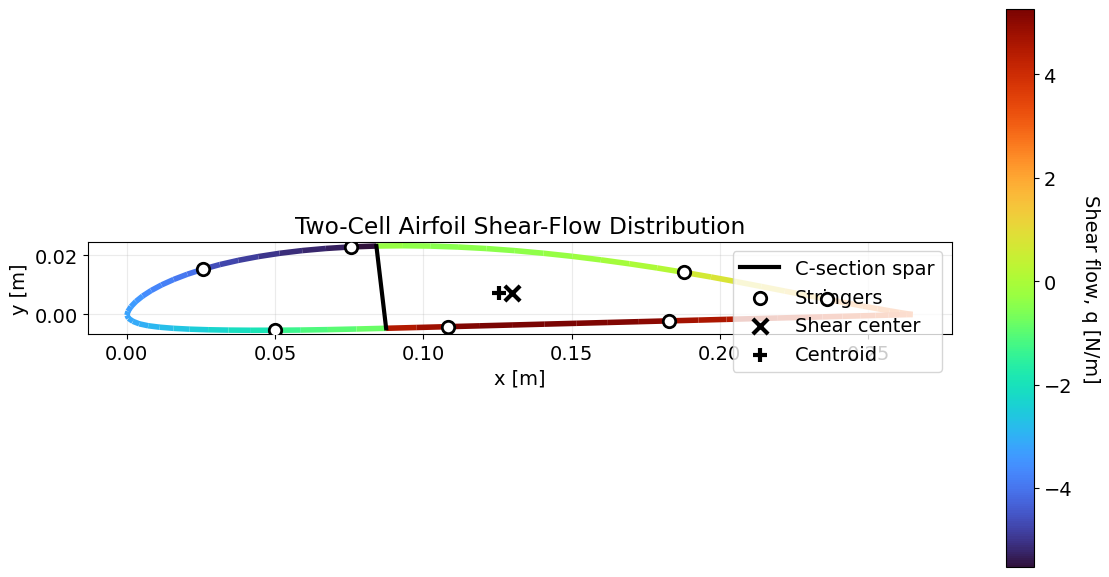

In [34]:
# ================================================================
# COLOURMAP OF SHEAR-FLOW DISTRIBUTION
# ================================================================

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ------------------------------------------------
# 1. SHEAR FLOW TO PLOT
# ------------------------------------------------
#
# Use the final shear flow if it has already been
# calculated.
#
# q_final = q_skin_global + q_T
#
# If you have not added the CP-induced torque yet,
# use:
#
# q_final = q_skin_global
# ------------------------------------------------

# q_final = q_skin_global + q_T


# ------------------------------------------------
# 2. CREATE LINE SEGMENTS FOR EVERY AIRFOIL PANEL
# ------------------------------------------------

segments = []

for i in range(n):

    j = (i + 1) % n

    segments.append([
        [x[i], y[i]],
        [x[j], y[j]]
    ])


segments = np.asarray(segments)


# ------------------------------------------------
# 3. COLOUR NORMALISATION
# ------------------------------------------------

q_min = np.min(q_final)
q_max = np.max(q_final)

norm = Normalize(
    vmin=q_min,
    vmax=q_max
)


# ------------------------------------------------
# 4. AIRFOIL COLOURMAP
# ------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

lc = LineCollection(
    segments,
    cmap="turbo",
    norm=norm,
    linewidth=4
)

lc.set_array(q_final)

ax.add_collection(lc)


# ------------------------------------------------
# 5. DRAW THE SPAR
# ------------------------------------------------

ax.plot(
    [
        x[upper_spar_index],
        x[lower_spar_index]
    ],
    [
        y[upper_spar_index],
        y[lower_spar_index]
    ],
    color="black",
    linewidth=3,
    label="C-section spar",
    zorder=5
)


# ------------------------------------------------
# 6. DRAW STRINGERS
# ------------------------------------------------

# Upper stringers

ax.scatter(
    x[upper_stringer_indices],
    y[upper_stringer_indices],
    s=80,
    marker="o",
    facecolors="white",
    edgecolors="black",
    linewidths=2,
    label="Stringers",
    zorder=6
)


# Lower stringers

ax.scatter(
    x[lower_stringer_indices],
    y[lower_stringer_indices],
    s=80,
    marker="o",
    facecolors="white",
    edgecolors="black",
    linewidths=2,
    zorder=6
)


# ------------------------------------------------
# 7. MARK SHEAR CENTER
# ------------------------------------------------

ax.scatter(
    x_SC,
    y_centroid_pt,
    s=120,
    marker="x",
    color="black",
    linewidths=3,
    label="Shear center",
    zorder=7
)


# ------------------------------------------------
# 8. MARK CENTROID
# ------------------------------------------------

ax.scatter(
    x_centroid_pt,
    y_centroid_pt,
    s=100,
    marker="+",
    color="black",
    linewidths=3,
    label="Centroid",
    zorder=7
)


# ------------------------------------------------
# 9. COLOURBAR
# ------------------------------------------------

cbar = fig.colorbar(lc, ax=ax)

cbar.set_label(
    "Shear flow, q [N/m]",
    rotation=270,
    labelpad=20
)


# ------------------------------------------------
# 10. AXES / FORMAT
# ------------------------------------------------

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

ax.set_title(
    "Two-Cell Airfoil Shear-Flow Distribution"
)

ax.grid(True, alpha=0.25)

ax.legend(
    loc="best"
)

plt.tight_layout()
plt.show()